# For Model Validation (Or Testing)


Initializing ShardStreamIterableDataset...
--> Scanning shards for metadata...


Scanning Shards: 100%|██████████| 150/150 [00:00<00:00, 1105.34it/s]

Size of all shards combined: 0.6673 GB
--> MODE: No stats provided. Yielding RAW, UNNORMALIZED labels.
Dataset initialized with 76354 events.
Loaded config from checkpoint:
  Model    : RNO_four_residual_merge | hidden_units=32 | temporal_res=256
  Manifest : /data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/manifest_builder/manifests/manifest_3albums_500comp.json
  Training : lr=0.001 | wd=0.0001 | min_hits=1
--- Starting Evaluation Pipeline ---
Executing evaluation on: cuda:1
Loading evaluation dataset from: <utils_dir.dataset.ShardStreamIterableDataset object at 0x7f2a63e5d6c0>
Dataset loaded. Total batches to evaluate: 150
Loading weights from: checkpoint_min_e38.pth...


Checkpoint successfully loaded into model on cuda:1!
Trained unnormalized statistics (Loaded from Buffer):
  X = 2.9969 ± 1337.9773
  Y = 15.6175 ± 1338.9883
  Z = -782.9150 ± 419.2670
Starting forward passes...


Evaluating: 100%|██████████| 150/150 [00:32<00:00,  4.62it/s]


Inference complete. Formatting output arrays...
Converting Cartesian coordinates (X, Y, Z) to Spherical (R, Theta, Phi)...
--- Evaluation Finished! ---
Shape of True array: (76354, 3)
Shape of Reco array: (76354, 3)
--- Relative Radius (R) Error Statistics ---
Mean Error:   -0.2109 (-21.09%)
Median Error: -0.2416 (-24.16%)
Spread (Std): 0.2840 (28.40%)
--------------------------------------------
Sigma 68%:    0.2207 (22.07%)
68% Interval: [-0.4448, -0.0034]


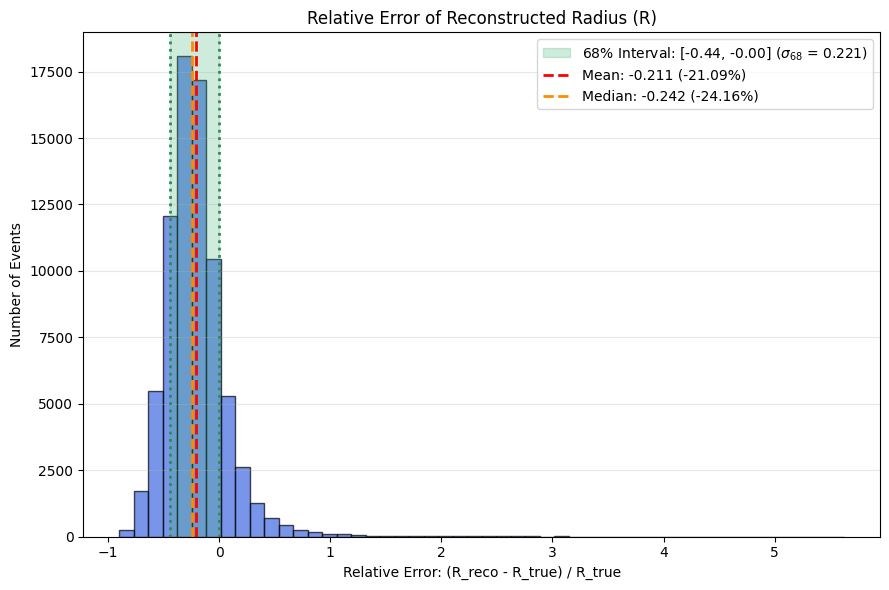

--- 3D Euclidean Distance Error (meters) ---
Mode:              295.0 m  (most common error)
Median:            573.7 m
Mean:              749.4 m
Std:               578.2 m
--------------------------------------------
68% containment:   854.4 m  (68% of events within this distance)


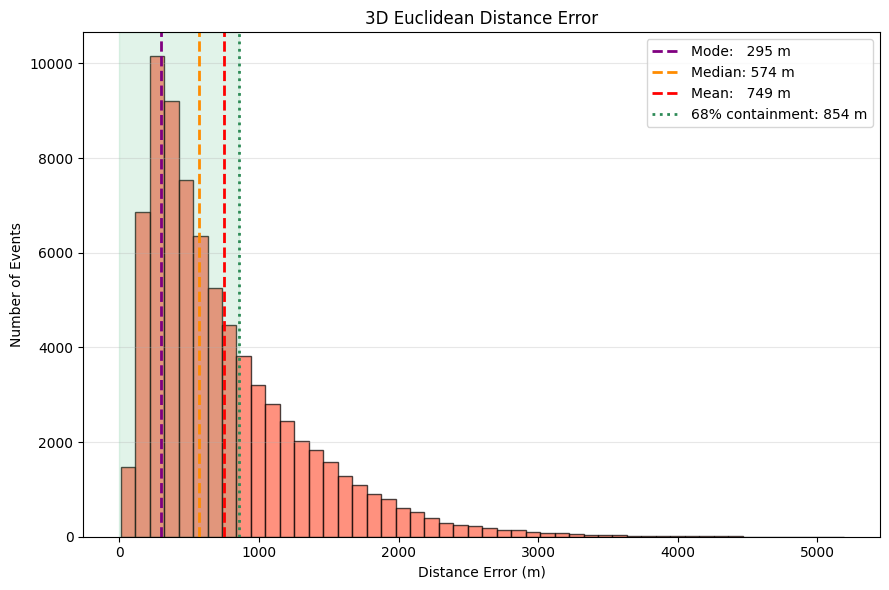

Saved to /data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/eval_log.json
  rel_R    68%: [-0.4448, -0.0034]  σ68=0.2207
  dist     mode=295.0m  68% containment=854.4m
  epoch    38


In [1]:
import numpy as np
from utils_dir import eval_utils

# ====================================================================
# CONFIG — only this changes between runs
# ====================================================================
CHECKPOINT_DIR = '/data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/model_experiments/model_RNO4_thesis/experiments/sx4h2s9j/checkpoints'
BATCH_SIZE     = 512
LOG_PATH       = '/data/condor_shared/users/ssued/RNO_vertex_reconstruction_ml/RNO_machine_learning/eval_log.json'
# ====================================================================

# Automatically resolves model class, hyperparameters, and val dataset
# from the checkpoint's saved model_config — no manual specification needed
evaluator = eval_utils.ModelEvaluator.from_checkpoint(
    checkpoint_path = CHECKPOINT_DIR,
    batch_size      = BATCH_SIZE,
    spherical       = True,
    device          = 'cuda:1'
)

rel_R = evaluator.show_rel_R(hist=True)
dist  = evaluator.show_euclidean_distance(hist=True)

# Append results to the shared log — overwrites if this experiment already exists
evaluator.save_to_log(
    experiment_name = 'sx4h2s9j',  # WandB run ID or any descriptive name
    log_path        = LOG_PATH
)